In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('rfm_scored.csv')
df.head()

,customer_key,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,1,270.0,3,8249,2.0,5,5,2.055
1,2,49.0,3,6384,5.0,5,5,5.055
2,3,339.0,3,8114,1.0,5,5,1.055
3,4,263.0,3,8139,2.0,5,5,2.055
4,5,272.0,3,8196,2.0,5,5,2.055


In [ ]:
from sklearn.cluster import KMeans

# Select the features for clustering
X = df[['R_Score', 'F_Score', 'M_Score']]

# Drop rows with NaN in the selected features for clustering
X_cleaned = X.dropna(subset=['R_Score', 'F_Score', 'M_Score'])

# Initialize KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Initialize 'Cluster' column with NaN for all rows
df['Cluster'] = float('nan')

# Get indices of cleaned data to map clusters back to the original DataFrame
original_indices = X_cleaned.index

# Fit KMeans to the cleaned data and assign clusters to the corresponding rows
df.loc[original_indices, 'Cluster'] = kmeans.fit_predict(X_cleaned)

print("Distribution of customers across clusters:")
display(df['Cluster'].value_counts(dropna=False))

print("\nMean RFM scores per cluster:")
display(df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].mean())

Distribution of customers across clusters:


,count
Cluster,
0.0,6199
1.0,5612
3.0,3430
2.0,3241
NaN,2



Mean RFM scores per cluster:


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Cluster,,,,,,,
0.0,208.536861,2.133247,3908.718826,2.940474,4.446362,4.509437,2.989447
1.0,285.788311,1.026550,403.964897,1.661796,2.049537,2.066108,1.684358
2.0,93.702561,1.000000,740.176797,4.162296,1.444307,2.730639,4.179469
3.0,87.186589,1.583382,134.141108,4.227697,3.411662,1.909038,4.263722


In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0.0,6199
1.0,5612
3.0,3430
2.0,3241


In [4]:
import pandas as pd
from sklearn.cluster import KMeans

# Load the data
df = pd.read_csv('rfm_scored.csv')

# Select the features for clustering
X = df[['R_Score', 'F_Score', 'M_Score']]

# Drop rows with NaN in the selected features for clustering
X_cleaned = X.dropna(subset=['R_Score', 'F_Score', 'M_Score'])

# Initialize KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Initialize 'Cluster' column with NaN for all rows
df['Cluster'] = float('nan')

# Get indices of cleaned data to map clusters back to the original DataFrame
original_indices = X_cleaned.index

# Fit KMeans to the cleaned data and assign clusters to the corresponding rows
df.loc[original_indices, 'Cluster'] = kmeans.fit_predict(X_cleaned)

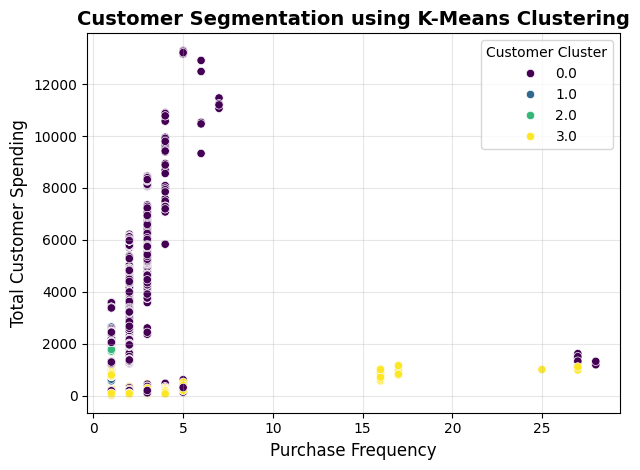

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans

# Load the data
df = pd.read_csv('rfm_scored.csv')

# Select the features for clustering
X = df[['R_Score', 'F_Score', 'M_Score']]

# Drop rows with NaN in the selected features for clustering
X_cleaned = X.dropna(subset=['R_Score', 'F_Score', 'M_Score'])

# Initialize KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Initialize 'Cluster' column with NaN for all rows
df['Cluster'] = float('nan')

# Get indices of cleaned data to map clusters back to the original DataFrame
original_indices = X_cleaned.index

# Fit KMeans to the cleaned data and assign clusters to the corresponding rows
df.loc[original_indices, 'Cluster'] = kmeans.fit_predict(X_cleaned)

sns.scatterplot(
    data=df,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title(
    'Customer Segmentation using K-Means Clustering',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Purchase Frequency',
    fontsize=12
)

plt.ylabel(
    'Total Customer Spending',
    fontsize=12
)

plt.legend(
    title='Customer Cluster'
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
df.groupby('Cluster').mean()

,customer_key,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Cluster,,,,,,,,
0.0,7863.949831,208.536861,2.133247,3908.718826,2.940474,4.446362,4.509437,2.989447
1.0,10435.471133,285.788311,1.026550,403.964897,1.661796,2.049537,2.066108,1.684358
2.0,8028.278618,93.702561,1.000000,740.176797,4.162296,1.444307,2.730639,4.179469
3.0,10928.532653,87.186589,1.583382,134.141108,4.227697,3.411662,1.909038,4.263722
